In [2]:
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import TTestIndPower
import pandas as pd

In [2]:
import json
from google.cloud import secretmanager
from google.cloud import bigquery
from google.oauth2 import service_account

# -----------------------------
# 1. Read service account JSON from Secret Manager
# -----------------------------
secret_project_id = "project-business-prd"
secret_id = "reyna_service_account"
version_id = "latest"
secret_client = secretmanager.SecretManagerServiceClient()
secret_name = (
    f"projects/{secret_project_id}/secrets/{secret_id}/versions/{version_id}"
)
response = secret_client.access_secret_version(
    request={"name": secret_name}
)
service_account_info = json.loads(
    response.payload.data.decode("UTF-8")
)
# -----------------------------
# 2. Create credentials from JSON
# -----------------------------
credentials = service_account.Credentials.from_service_account_info(
    service_account_info
)

## T Test

In [3]:
# load from bq
bq_project_id = "project-business-prd"
dataset_id = "prism_studio"
table_id = "experiment_raw_data_ttest"
client = bigquery.Client(
     project=bq_project_id,
     credentials=credentials
 )
full_table_id = f"{bq_project_id}.{dataset_id}.{table_id}"
df = client.query(f'select * from `{full_table_id}`').to_dataframe()
print(df.head())

/Users/reynafeng/Documents/Git/experiment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


     group       value
0  control  107.450712
1  control   97.926035
2  control  109.715328
3  control  122.845448
4  control   96.487699


In [ ]:
# simulate data
np.random.seed(42)
n_control = 50
n_treatment = 50
control = np.random.normal(loc=100, scale=15, size=n_control)
treatment = np.random.normal(loc=108, scale=15, size=n_treatment)

df = pd.DataFrame({
    'group': ['control'] * n_control + ['treatment'] * n_treatment,
    'value': np.concatenate([control, treatment])
})

In [4]:
# write welch t test function
def welch_ttest(group1, group2):
    group1 = np.array(group1)
    group2 = np.array(group2)
    n_1 = len(group1)
    n_2 = len(group2)
    mean_1 = np.mean(group1)
    mean_2 = np.mean(group2)
    var_1 = np.var(group1, ddof=1)
    var_2 = np.var(group2, ddof=1)
    se = np.sqrt(var_1 / n_1 + var_2 / n_2)
    t_stat = (mean_1 - mean_2) / se
    numerator = (var_1 / n_1 + var_2 / n_2) ** 2
    denominator = ((var_1 / n_1) ** 2) / (n_1 - 1) + ((var_2 / n_2) ** 2) / (n_2 - 1)
    df = numerator / denominator
    # two side p value
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df))
    return t_stat, p_value

In [5]:
# run test
control_data = df[df["group"] == "control"]["value"]
treatment_data = df[df["group"] == "treatment"]["value"]
welch_result = welch_ttest(treatment_data, control_data)
t_stat, p_value = stats.ttest_ind(treatment_data, control_data, equal_var=False)
print('welch_result: ',welch_result)
print('t stats result: ',t_stat, p_value)

welch_result:  (np.float64(4.292991111876886), np.float64(4.161002771985167e-05))
t stats result:  4.292991111876886 4.161002771977085e-05


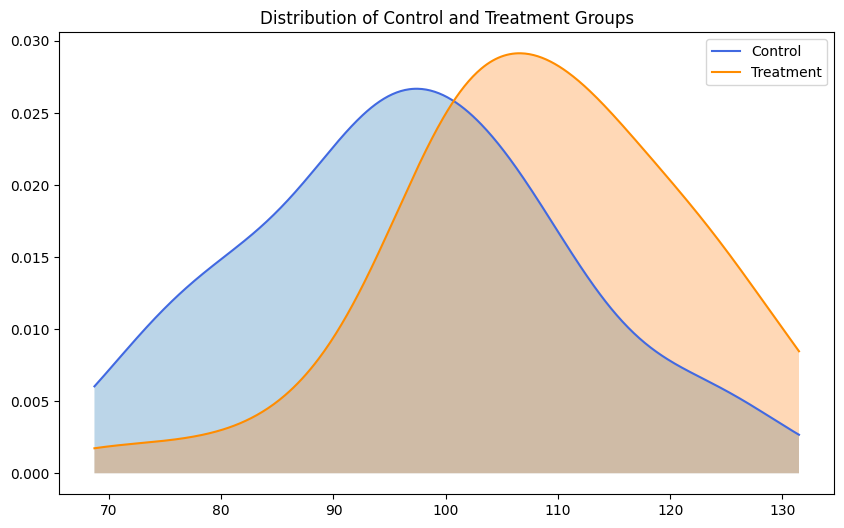

In [8]:
# distribution chart
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
x = np.linspace(min(df["value"]), max(df["value"]), 500)
control_kde = gaussian_kde(control_data)
treatment_kde = gaussian_kde(treatment_data)
control_density = control_kde(x)
treatment_density = treatment_kde(x)
plt.figure(figsize=(10, 6))
plt.plot(x, control_density, label='Control', color='royalblue')
plt.fill_between(x, control_density, alpha=0.3)
plt.plot(x, treatment_density, label='Treatment', color='darkorange')
plt.fill_between(x, treatment_density, alpha=0.3)
plt.title('Distribution of Control and Treatment Groups')
plt.legend()
plt.show()

In [7]:
# -----------------------------
# 3. Load dataframe to BigQuery
# -----------------------------
bq_project_id = "project-business-prd"
dataset_id = "prism_studio"
table_id = "experiment_raw_data_ttest"

client = bigquery.Client(
    project=bq_project_id,
    credentials=credentials
)
full_table_id = f"{bq_project_id}.{dataset_id}.{table_id}"
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    create_disposition="CREATE_IF_NEEDED"
)
job = client.load_table_from_dataframe(
    df,
    full_table_id,
    job_config=job_config
)
job.result()
print(f"Loaded {len(df):,} rows to {full_table_id}")

/Users/reynafeng/Documents/Git/experiment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Loaded 100 rows to project-business-prd.prism_studio.experiment_raw_data_ttest


## Z Test

In [10]:
np.random.seed(42)
n=100
df = pd.DataFrame({
    'group': np.random.choice(['control','treatment'],size=n)
})
df['converted'] = np.where(df['group'] == 'control', np.random.binomial(1, 0.1, size=n), np.random.binomial(1, 0.18, size=n))
print(df.head())

       group  converted
0    control          1
1  treatment          0
2    control          1
3    control          0
4    control          0


In [11]:
summary = df.groupby('group')['converted'].agg(['sum','count'])
success = np.array([summary.loc['control','sum'],summary.loc['treatment','sum']])
total = np.array([summary.loc['control','count'],summary.loc['treatment','count']])
z_stat, p_value = proportions_ztest(success,total)
print('z stat: ', z_stat, 'p value: ', p_value)

z stat:  -1.4101901870444153 p value:  0.15848353257474201


In [12]:
def manual_ztest(control_success, control_total, treatment_success, treatment_total):
    p1 = control_success / control_total
    p2 = treatment_success / treatment_total
    p_pool = (control_success + treatment_success) / (control_total + treatment_total)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/control_total + 1/treatment_total))
    z_stat = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    return z_stat, p_value

In [13]:
result = manual_ztest(summary.loc['control','sum'], summary.loc['control','count'], summary.loc['treatment','sum'], summary.loc['treatment','count'])
print('manual z stat: ', result[0], 'manual p value: ', result[1])

manual z stat:  -1.4101901870444153 manual p value:  0.15848353257474201


## Chi Square Test

In [14]:
np.random.seed(42)
n = 100
df = pd.DataFrame({
    'group': np.random.choice(['control', 'treatment'], size=n)
})
df['clicked'] = np.where(df['group'] == 'control', np.random.binomial(1, 0.2, size=n), np.random.binomial(1,0.35, size=n))
print(df.head())

       group  clicked
0    control        1
1  treatment        0
2    control        1
3    control        1
4    control        0


In [15]:
table = pd.crosstab(df['group'],df['clicked'])
table.columns = ['not_clicked','clicked']
print(table)

           not_clicked  clicked
group                          
control             33       11
treatment           35       21


In [16]:
from scipy.stats import chi2_contingency, chi2
chi2_stat, p_value, dof, expected = chi2_contingency(table)
print('chi2 stat: ', chi2_stat, 'p value: ', p_value)

chi2 stat:  1.2414802568754764 p value:  0.2651859628362063


In [17]:
def manual_chi_square_test(observed):
    observed = np.array(observed)
    row_totals = observed.sum(axis=1)
    col_totals = observed.sum(axis=0)
    grand_total = observed.sum()
    expected = np.outer(row_totals, col_totals) / grand_total
    chi2_stat = ((observed - expected) ** 2 / expected).sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)
    p_value = 1 - chi2.cdf(chi2_stat, dof)
    return chi2_stat, p_value

In [19]:
manual_chi_square_test(table.values)
print('manual chi2 stat: ', manual_chi_square_test(table)[0], 'manual p value: ', manual_chi_square_test(table)[1])

manual chi2 stat:  1.7693014705882342 manual p value:  0.1834685511795171


## Fisher Test

In [23]:
np.random.seed(42)
n = 100
df = pd.DataFrame({
    'group':np.random.choice(['control','treatment'],size=n)
})
df['converted'] = np.where(
    df['group'] == 'control',
    np.random.binomial(1,0.1, size=n),
    np.random.binomial(1,0.25,size=n)
)

In [24]:
table = pd.crosstab(df['group'],df['converted'])
table.columns = ['not_converted','converted']
print(table)

           not_converted  converted
group                              
control               38          6
treatment             40         16


In [25]:
from scipy.stats import fisher_exact
odds_ratio, p_value = fisher_exact(table)
print('odds ratio: ', odds_ratio, 'p value: ', p_value)

odds ratio:  2.533333333333333 p value:  0.09122490190983898


In [26]:
from math import factorial
def combination(n,r):
    # factorial: n! = n x (n-1) x (n-2) x ... x 1
    return factorial(n) / (factorial(r) * factorial(n-r))
def fisher_probability(a,b,c,d):
    """
    2x2 table:
                converted   not_converted
    control         a              b
    treatment       c              d
    """
    numerator = (combination(a+b,a) * combination(c+d,c))
    denominator = combination(a+b+c+d,a+c)
    return numerator / denominator

In [27]:
a = table.loc['control','converted']
b = table.loc['control','not_converted']
c = table.loc['treatment','converted']
d = table.loc['treatment','not_converted']
manual_p_value = fisher_probability(a,b,c,d)
print('manual p value: ', manual_p_value)

manual p value:  0.04009812258808965


In [28]:
# hyperdistribution: draw ball from total and don't put back
from scipy.stats import hypergeom
N = 1000 #total population
K = 30 # total success in population
n = 20 # sample size
x_values = np.arange(0, n+1)
probs = hypergeom.pmf(x_values, N, K, n)
hyper_df = pd.DataFrame({
    'success_in_sample': x_values,
    'probability': probs
})
print(hyper_df.head())

   success_in_sample  probability
0                  0     0.540566
1                  1     0.341051
2                  2     0.098697
3                  3     0.017399
4                  4     0.002093


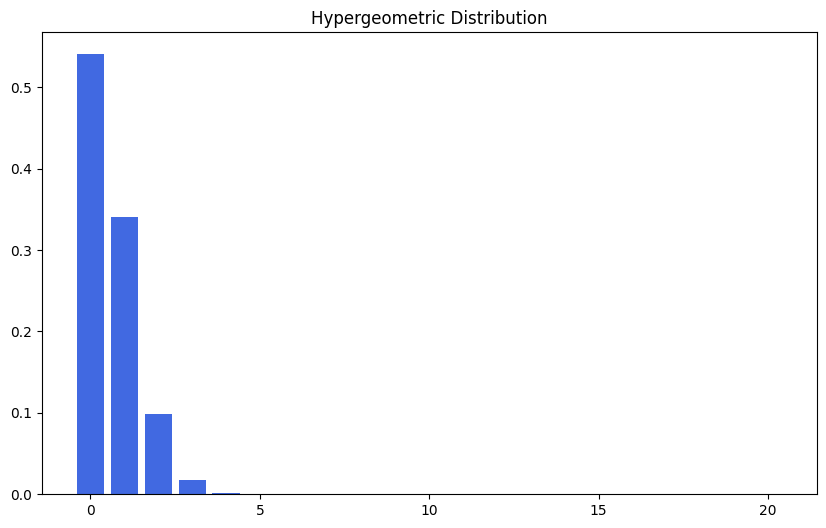

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(hyper_df['success_in_sample'],hyper_df['probability'],color='royalblue')
plt.title('Hypergeometric Distribution')
plt.show()

when data is hypergeometric distribution, can use:  
1. Fisher Exact Test 
2. Hypergeometric Test 
3. Permutation Test 
4. Randomization Test 
5. Exact Binomial Test 
6. Chi-square Test

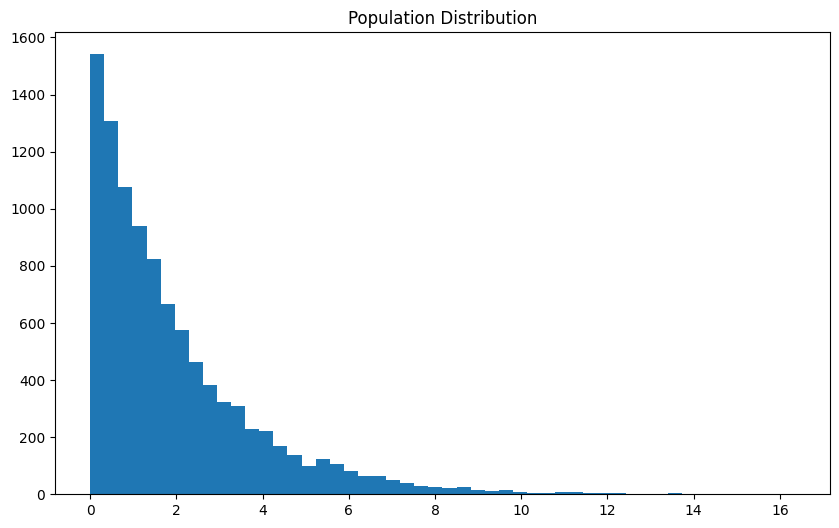

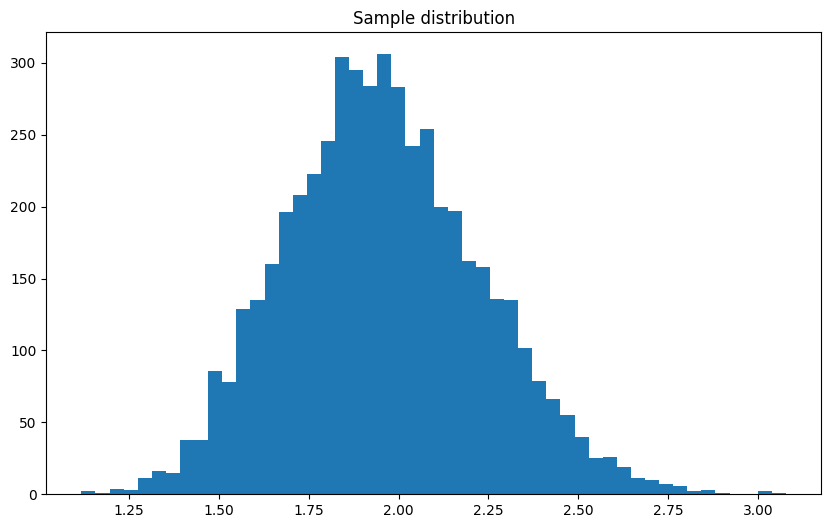

In [30]:
# when data is large enough, binomial can still use z test through CLT
np.random.seed(42)
population = np.random.exponential(scale=2, size=10000)
sample_size = 50
num_samples = 5000
sample_mean = []
for _ in range(num_samples):
    sample = np.random.choice(population,size=sample_size,replace=True)
    sample_mean.append(sample.mean())
sample_means = np.array(sample_mean)
plt.figure(figsize=(10,6))
plt.hist(population,bins=50)
plt.title('Population Distribution')
plt.show()
plt.figure(figsize=(10,6))
plt.hist(sample_means,bins=50)
plt.title('Sample distribution')
plt.show()

## Mann Whitney U Test

In [ ]:
# when data is highly skewed distribution
np.random.seed(42)
n = 100
df = pd.DataFrame({
    'group': np.random.choice(['control','treatment'],size=n)
})
df['revenue'] = np.where(df['group']=='control',np.random.exponential(scale=100,size=n),np.random.exponential(scale=120,size=n))

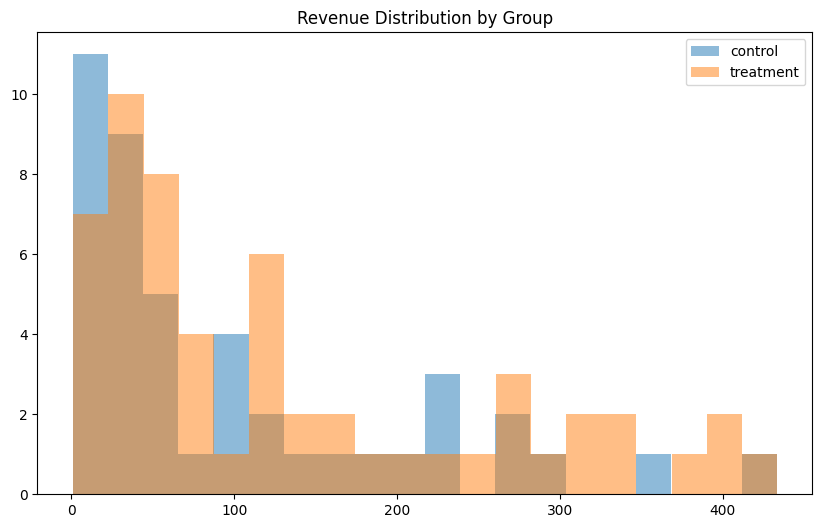

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
for grp in ['control','treatment']:
    subset = df[df['group'] == grp]['revenue']
    plt.hist(subset,bins=20,alpha=0.5,label=grp)
plt.title('Revenue Distribution by Group')
plt.legend()
plt.show()

In [5]:
control_data = df[df['group']=='control']['revenue']
treatment_data = df[df['group']=='treatment']['revenue']
u_stat, p_value = stats.mannwhitneyu(treatment_data,control_data,alternative='two-sided')
print('mannwhitneyu stat: ', u_stat, 'p value: ', p_value)

mannwhitneyu stat:  1450.0 p value:  0.13096190415101117


In [ ]:
# core idea: rank all observations together then compare rank sums
# Use Mann-Whitney U when comparing two independent groups and the data does NOT satisfy normality assumptions required for a t-test.
# revenue/user (highly skewed), session duration (long-tail), purchase amount (outliers)
from scipy.stats import rankdata
def manual_mannwhitneyu(group1, group2):
    group1 = np.array(group1)
    group2 = np.array(group2)
    combined = np.concatenate([group1, group2])
    ranks = rankdata(combined)
    ranks_1 = ranks[:len(group1)]
    ranks_2 = ranks[len(group1):]
    rank_sum_1 = ranks_1.sum()
    rank_sum_2 = ranks_2.sum()
    n1 = len(group1)
    n2 = len(group2)
    u1 = rank_sum_1 - n1 * (n1 + 1) / 2
    u2 = rank_sum_2 - n2 * (n2 + 1) / 2
    u_stat = min(u1, u2)
    mean_u = n1 * n2 / 2
    std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z_stat = (u_stat - mean_u) / std_u
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    return u_stat, p_value

In [7]:
manual_result = manual_mannwhitneyu(treatment_data, control_data)
print('manual mannwhitneyu stat: ', manual_result[0], 'manual p value: ', manual_result[1])

manual mannwhitneyu stat:  1014.0 manual p value:  0.13007871528049164


## ANOVA Test

In [9]:
# instead of A/B test only two group, when there are 3 groups, we can use ANOVA
np.random.seed(42)
n = 120
groups = np.random.choice(['variant_a','variant_b','variant_c'],size=n)
df = pd.DataFrame({
    'group':groups
})
df['revenue'] = np.select(
   [df['group'] == 'variant_a',
    df['group'] == 'variant_b',
    df['group'] == 'variant_c'],
   [np.random.normal(100, 15, size=n),
    np.random.normal(110, 15, size=n),
    np.random.normal(130, 15, size=n)]
)
print(df.head())

       group     revenue
0  variant_c  138.276055
1  variant_a   86.526881
2  variant_c  103.184926
3  variant_c  111.691448
4  variant_a   84.432552


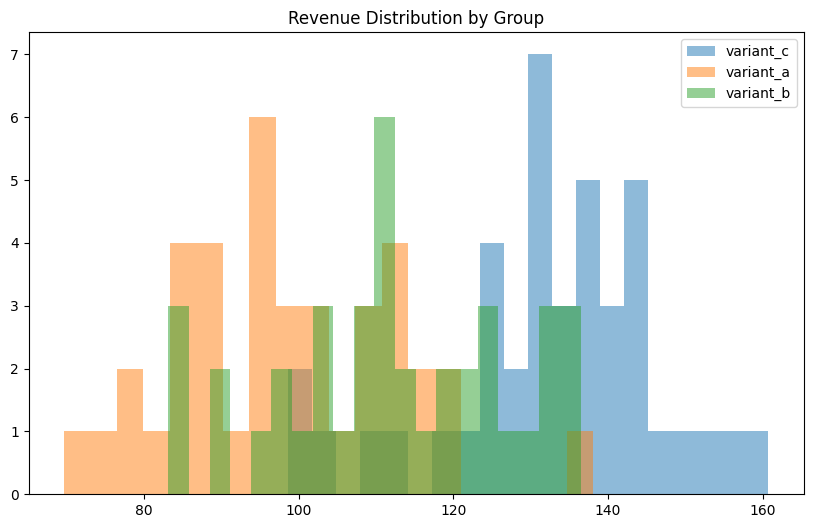

In [10]:
plt.figure(figsize=(10,6))
for grp in df['group'].unique():
    subset = df[df['group'] == grp]['revenue']
    plt.hist(subset,bins=20,alpha=0.5,label=grp)
plt.title('Revenue Distribution by Group')
plt.legend()
plt.show()

In [11]:
group_a = df[df['group']=='variant_a']['revenue']
group_b = df[df['group']=='variant_b']['revenue']
group_c = df[df['group']=='variant_c']['revenue']
f_stat, p_value = stats.f_oneway(group_a, group_b, group_c)
print('f stat: ', f_stat, 'p value: ', p_value)

f stat:  56.706523850680526 p value:  6.056328293958511e-18


In [12]:
# between-group variance vs within-group variance
def manual_anova(*groups):
    all_values = np.concatenate(groups)
    overall_mean = np.mean(all_values)
    ss_between = 0
    for g in groups:
        ss_between += len(g) * (np.mean(g) - overall_mean) ** 2
    ss_within = 0
    for g in groups:
        ss_within += np.sum((g - np.mean(g)) ** 2)
    k = len(groups)
    n_total = len(all_values)
    df_between = k - 1
    df_within = n_total - k
    ms_between = ss_between / df_between
    ms_within = ss_within / df_within
    f_stat = ms_between / ms_within
    p_value = 1 - stats.f.cdf(f_stat, df_between, df_within)
    return f_stat, p_value

In [13]:
manual_result = manual_anova(group_a.values, group_b.values, group_c.values)
print('manual anova f stat: ', manual_result[0], 'manual anova p value: ', manual_result[1])

manual anova f stat:  56.7065238506806 manual anova p value:  0.0


## Bootstrap

In [15]:
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'group':np.random.choice(['control','treatment'],size=n)
})
df['revenue'] = np.where(
    df['group'] == 'control',
    np.random.exponential(scale=100,size=n),
    np.random.exponential(scale=120,size=n)
)

bootstrap 95% CI for mean difference:  (np.float64(3.8393442209149855), np.float64(31.1630491770687))


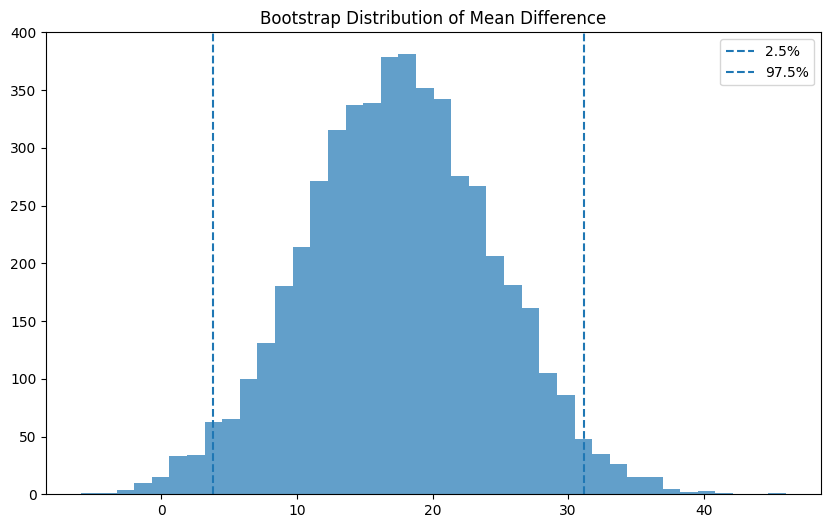

In [16]:
# use boostrap: data non-normal, skewed distributions, outliers, unknown analytical distribution, robust confidence intervals needed
control_data = df[df['group']=='control']['revenue'].values
treatment_data = df[df['group']=='treatment']['revenue'].values
n_bootstrap = 5000
bootstrap_diff = []
for _ in range(n_bootstrap):
    control_sample = np.random.choice(control_data,size=len(control_data),replace=True)
    treatment_sample = np.random.choice(treatment_data,size=len(treatment_data),replace=True)
    diff = np.mean(treatment_sample) - np.mean(control_sample)
    bootstrap_diff.append(diff)
bootstrap_diff = np.array(bootstrap_diff)
lower = np.percentile(bootstrap_diff, 2.5)
upper = np.percentile(bootstrap_diff, 97.5)
print('bootstrap 95% CI for mean difference: ', (lower, upper))
plt.figure(figsize=(10,6))
plt.hist(bootstrap_diff,bins=40,alpha=0.7)
plt.axvline(lower,linestyle='--',label='2.5%')
plt.axvline(upper,linestyle='--',label='97.5%')
plt.title('Bootstrap Distribution of Mean Difference')
plt.legend()
plt.show()

In [17]:
p_value = np.mean(bootstrap_diff <= 0)
print('bootstrap p value: ', p_value)

bootstrap p value:  0.0048


## Bonferroni Correction

## Power Analysis

## Bayesian Simulation